## Machine Learning Explainer Notebook for sbpa

In [299]:
# --- 1. Imports and Setup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [300]:
# --- 2. Configuration
# Load CSV
csv_path = "C:/Users/Charles Amegashie/Desktop/wallet_transactions.csv"
df = pd.read_csv(csv_path)

# Convert timestamp and filter debits
df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True)
df = df[df['type'] == 'debit'].copy()

# Add a 'month' column for grouping
df['month'] = df['timestamp'].dt.to_period('M')
df.head()


,wallet_id,user_id,source,amount,type,description,category,timestamp,month
1,1,101,momo,80.57,debit,Movie ticket,transport,2024-04-02 01:49:00,2024-04
2,1,101,momo,258.18,debit,Bought groceries,entertainment,2024-04-02 05:20:00,2024-04
3,1,101,momo,234.80,debit,Uber ride,food,2024-04-02 09:01:00,2024-04
4,1,101,momo,122.03,debit,Netflix subscription,utilities,2024-04-02 09:54:00,2024-04
5,1,101,momo,396.85,debit,Electricity bill,utilities,2024-04-02 11:20:00,2024-04


In [301]:
monthly = df.groupby(['month', 'category'])['amount'].sum().reset_index()
monthly['month'] = monthly['month'].dt.to_timestamp()
monthly = monthly.sort_values(['category', 'month'])
monthly.head()


,month,category,amount
0,2024-04-01,airtime,4757.47
9,2024-05-01,airtime,6319.36
18,2024-06-01,airtime,4797.56
27,2024-07-01,airtime,3581.83
36,2024-08-01,airtime,6024.75


In [302]:
train_rows = []

for category in monthly['category'].unique():
    cat_df = monthly[monthly['category'] == category].reset_index(drop=True)
    
    for i in range(3, len(cat_df)):
        train_rows.append({
            'category': category,
            'month': cat_df.loc[i, 'month'],
            'prev_1': cat_df.loc[i-1, 'amount'],
            'prev_2': cat_df.loc[i-2, 'amount'],
            'prev_3': cat_df.loc[i-3, 'amount'],
            'target': cat_df.loc[i, 'amount']
        })

train_df = pd.DataFrame(train_rows)
train_df.head()


,category,month,prev_1,prev_2,prev_3,target
0,airtime,2024-07-01,4797.56,6319.36,4757.47,3581.83
1,airtime,2024-08-01,3581.83,4797.56,6319.36,6024.75
2,airtime,2024-09-01,6024.75,3581.83,4797.56,7179.30
3,airtime,2024-10-01,7179.30,6024.75,3581.83,4112.93
4,airtime,2024-11-01,4112.93,7179.30,6024.75,4421.46


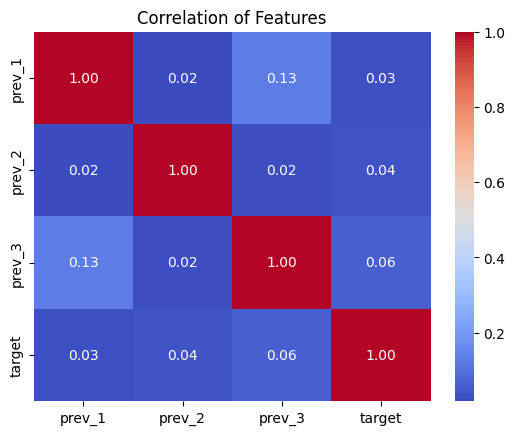

In [303]:
sns.heatmap(train_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation of Features')
plt.show()

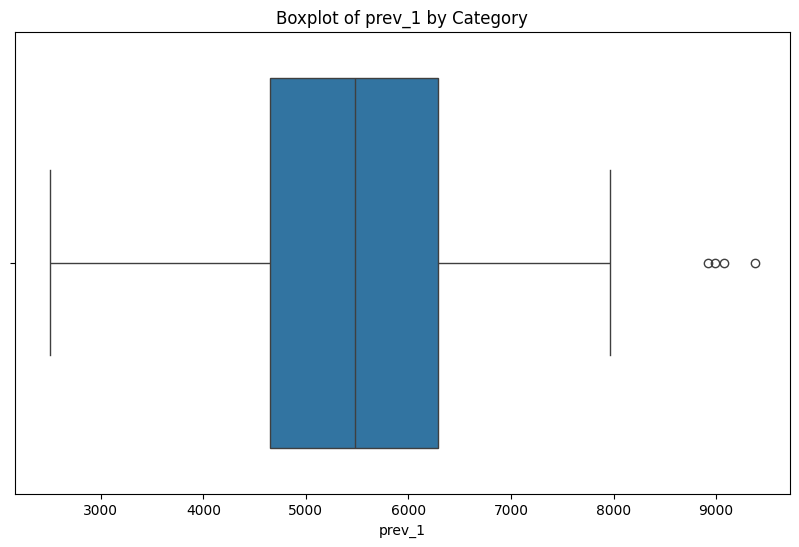

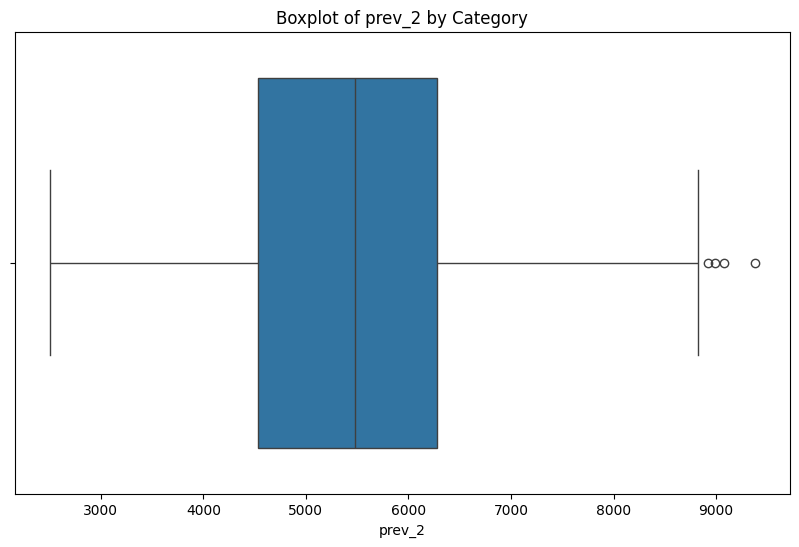

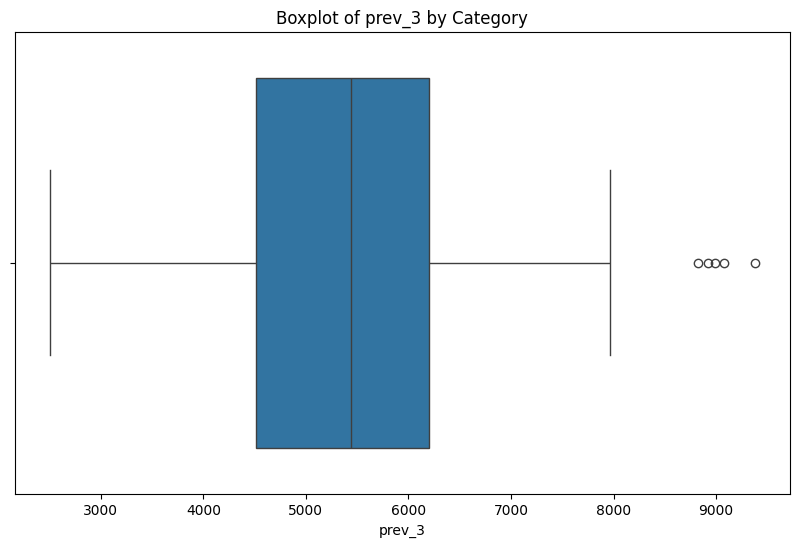

In [304]:
var = ["prev_1", "prev_2", "prev_3"]
for col in var:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x= col, data=train_df)
    plt.title(f'Boxplot of {col} by Category')
    plt.xticks(rotation=0)
    plt.show()


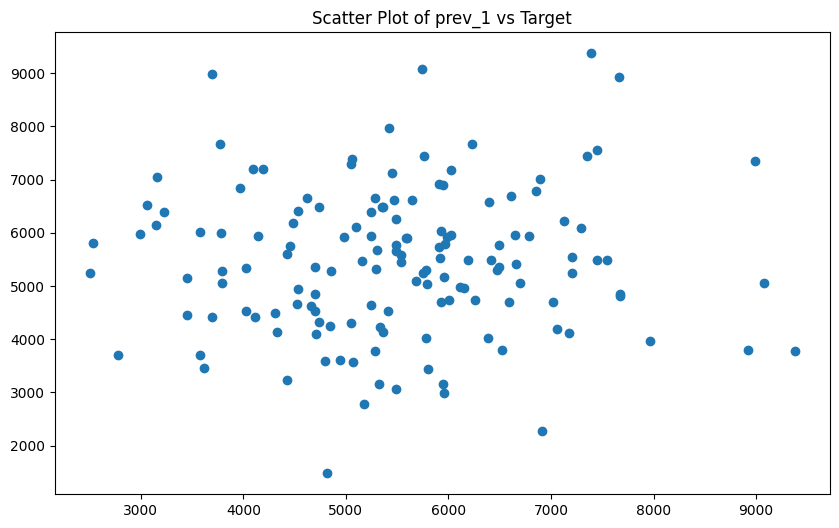

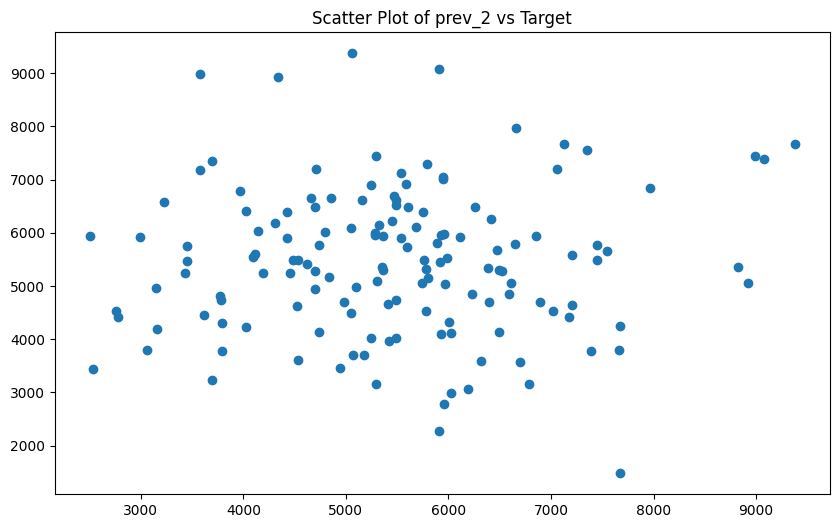

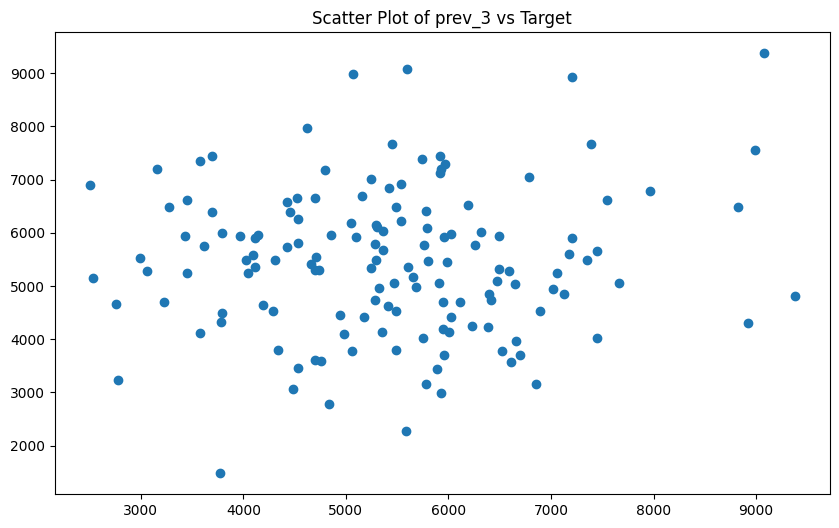

In [305]:
rav = ["prev_1", "prev_2", "prev_3"]
for col in rav:
    plt.figure(figsize=(10, 6))
    plt.scatter(train_df[col], train_df['target'])
    plt.title(f'Scatter Plot of {col} vs Target')
    plt.show()

In [306]:
cutoff = pd.to_datetime("2025-08-01")

train_set = train_df[train_df['month'] < cutoff]
test_set = train_df[train_df['month'] >= cutoff]

X_train = train_set[['prev_1', 'prev_2', 'prev_3']]
y_train = train_set['target']

X_test = test_set[['prev_1', 'prev_2', 'prev_3']]
y_test = test_set['target']


In [307]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [308]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [309]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Predict on test set
predictions = model.predict(X_test)

# Evaluate
r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)  # Manual RMSE calculation

print(f"Mean Absolute Error (MAE): GHS {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): GHS {rmse:.2f}")
print(f"R-squared: {r2:.2f}")





Mean Absolute Error (MAE): GHS 1240.56
Root Mean Squared Error (RMSE): GHS 1545.70
R-squared: -0.06


In [310]:
y_pred = model.predict(X_test)



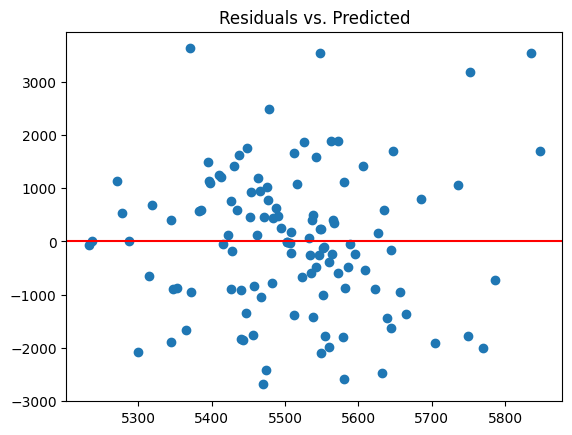

In [311]:
preds = model.predict(X_train)
residuals = y_train - preds

plt.scatter(preds, residuals)
plt.axhline(0, color='red')
plt.title("Residuals vs. Predicted")
plt.show()

C:\Users\Charles Amegashie\AppData\Local\Temp\ipykernel_10148\1929583795.py:24: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Charles Amegashie\Desktop\sbpa\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


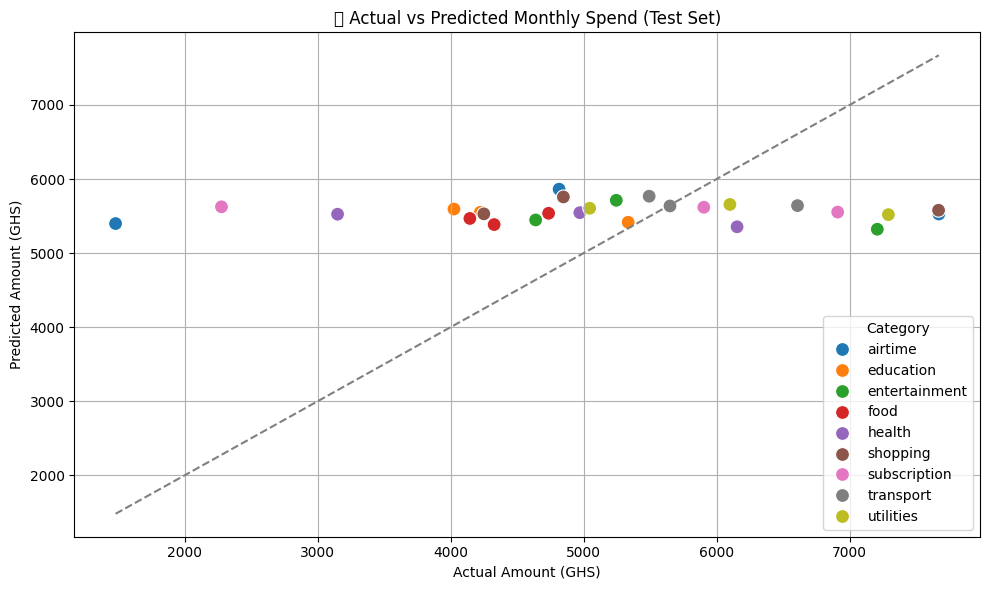

In [312]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Add predictions to test_set
test_plot_df = test_set.copy()
test_plot_df['predicted'] = y_pred
test_plot_df['actual'] = y_test.values
test_plot_df['error'] = test_plot_df['predicted'] - test_plot_df['actual']

# Plot actual vs predicted
plt.figure(figsize=(10, 6))
sns.scatterplot(data=test_plot_df, x='actual', y='predicted', hue='category', s=100)

# Add reference diagonal line (perfect prediction line)
min_val = min(test_plot_df['actual'].min(), test_plot_df['predicted'].min())
max_val = max(test_plot_df['actual'].max(), test_plot_df['predicted'].max())
plt.plot([min_val, max_val], [min_val, max_val], '--', color='gray')

plt.xlabel("Actual Amount (GHS)")
plt.ylabel("Predicted Amount (GHS)")
plt.title("📊 Actual vs Predicted Monthly Spend (Test Set)")
plt.grid(True)
plt.tight_layout()
plt.legend(title="Category")
plt.show()


In [313]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("📦 Model Evaluation Metrics")
print("-" * 30)
print(f"✅ MAE (Mean Absolute Error):      {mae:.2f} GHS")
print(f"✅ RMSE (Root Mean Squared Error): {rmse:.2f} GHS")
print(f"✅ R² Score (Explained Variance):  {r2:.2f}")


📦 Model Evaluation Metrics
------------------------------
✅ MAE (Mean Absolute Error):      1240.56 GHS
✅ RMSE (Root Mean Squared Error): 1545.70 GHS
✅ R² Score (Explained Variance):  -0.06


In [314]:
summary = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R² Score'],
    'Value': [round(mae, 2), round(rmse, 2), round(r2, 2)]
})

summary.style.set_caption("📊 Model Performance Summary")


,Metric,Value
0,MAE,1240.560000
1,RMSE,1545.700000
2,R² Score,-0.060000


In [315]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Store results here
results = []

# Models to compare
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({
        "Model": name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R²": round(r2, 2)
    })

# Convert to DataFrame for display
results_df = pd.DataFrame(results)
results_df


,Model,MAE,RMSE,R²
0,Linear Regression,1240.56,1545.70,-0.06
1,Decision Tree,1714.53,2073.21,-0.91
2,Random Forest,1453.35,1864.45,-0.55


## Rolling window evaluation

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Load cleaned CSV
df = pd.read_csv("C:/Users/Charles Amegashie/Desktop/wallet_transactions.csv", parse_dates=['timestamp'])

# Filter for debit transactions only
df = df[df['type'] == 'debit'].copy()

# Extract month period
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df['month'] = df['timestamp'].dt.to_period('M')
# Group by month and category
monthly = df.groupby(['month', 'category'])['amount'].sum().reset_index()
monthly['month'] = monthly['month'].dt.to_timestamp()



In [ ]:
# Create sliding windows per category
records = []
for category in monthly['category'].unique():
    cat_df = monthly[monthly['category'] == category].copy()
    cat_df.sort_values('month', inplace=True)
    cat_df['target'] = cat_df['amount'].shift(-1)

    for i in range(3, len(cat_df) - 1):
        records.append({
            'category': category,
            'month': cat_df.iloc[i]['month'],
            'prev_1': cat_df.iloc[i-1]['amount'],
            'prev_2': cat_df.iloc[i-2]['amount'],
            'prev_3': cat_df.iloc[i-3]['amount'],
            'target': cat_df.iloc[i]['target']
        })

train_df = pd.DataFrame(records)

In [ ]:
# Initialize model
model = LinearRegression()

# Store metrics
metrics = []
predictions_all = []

# Rolling window evaluation
months = sorted(train_df['month'].unique())
for test_month in months[3:]:
    train_set = train_df[train_df['month'] < test_month]
    test_set = train_df[train_df['month'] == test_month]

    if len(train_set) < 10 or len(test_set) == 0:
        continue

    X_train = train_set[['prev_1', 'prev_2', 'prev_3']]
    y_train = train_set['target']

    X_test = test_set[['prev_1', 'prev_2', 'prev_3']]
    y_test = test_set['target']

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    predictions_all.extend(list(zip(test_set['month'], test_set['category'], y_test, y_pred)))
    from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

metrics.append({
        'Month': test_month.strftime('%Y-%m'),
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'R2': round(r2, 2)
    })


In [ ]:
# Show metrics
eval_df = pd.DataFrame(metrics)
print("\n📦 Rolling Evaluation Metrics\n------------------------------")
print(eval_df)


📦 Rolling Evaluation Metrics
------------------------------
     Month     MAE    RMSE    R2
0  2025-11  782.61  939.05 -0.56


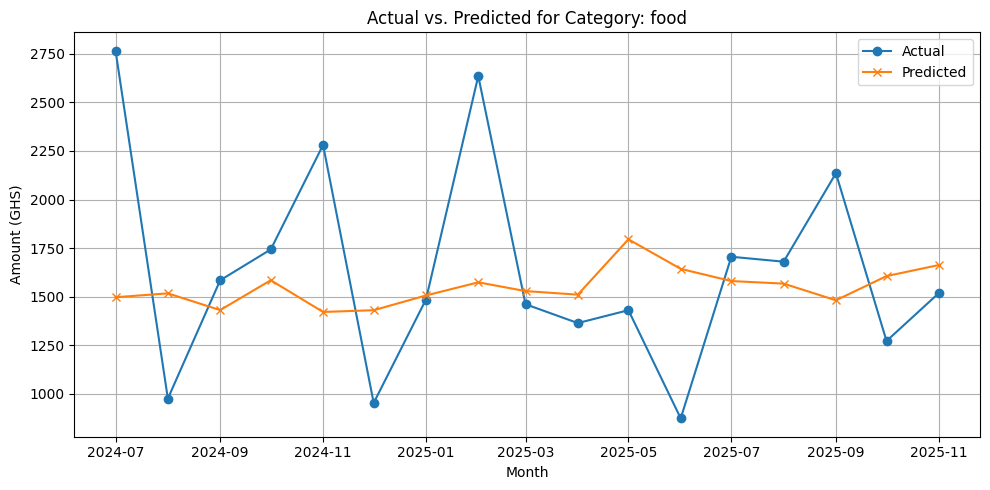

In [ ]:
# Optional: Plot predictions vs actuals for one category
plot_df = pd.DataFrame(predictions_all, columns=['month', 'category', 'actual', 'predicted'])
category_to_plot = "food"
cat_plot = plot_df[plot_df['category'] == category_to_plot]

plt.figure(figsize=(10, 5))
plt.plot(cat_plot['month'], cat_plot['actual'], label='Actual', marker='o')
plt.plot(cat_plot['month'], cat_plot['predicted'], label='Predicted', marker='x')
plt.title(f"Actual vs. Predicted for Category: {category_to_plot}")
plt.xlabel("Month")
plt.ylabel("Amount (GHS)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
